In [1]:
# Copyright (c) 2025-present, Mr Iwan T. Mitchell, Bangor University, All rights reserved.
# Copyright (c) 2025-present, Prof Franck P. Vidal, UK Research and Innovation, All rights reserved.
#
#
# Redistribution and use in source and binary forms, with or without modification,
# are permitted provided that the following conditions are met:
#
# 1. Redistributions of source code must retain the above copyright notice,
# this list of conditions and the following disclaimer.
#
# 2. Redistributions in binary form must reproduce the above copyright notice,
# this list of conditions and the following disclaimer in the documentation and/or
# other materials provided with the distribution.
#
# 3. Neither the name of Bangor University, UK Research and Innovation nor the
# names of its contributors may be used to endorse or promote products derived
# from this software without specific prior written permission.
#
# THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS" AND
# ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO,
# THE IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE
# ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE
# FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
# DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
# SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
# CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
# OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF
# THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.

Plot the detector energy response using the twin framework.

Import the packages

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from  gvxrPython3 import gvxr
from  gvxrPython3.twins import createDigitalTwin

Set Matplotlib's properties

In [ ]:
plt.style.use('tableau-colorblind10')

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

Create a DTHE twin

In [4]:
twin = createDigitalTwin(name="DTHE")

We must call the ``apply'' method of the twin to generate the detector energy response

In [5]:
twin.apply()

Tue Feb 17 14:18:34 2026 ---- Create window (ID: -1)
Tue Feb 17 14:18:34 2026 ---- Request an interactive OpenGL context
Tue Feb 17 14:18:34 2026 ---- Initialise GLFW
Tue Feb 17 14:18:34 2026 ---- Create an OpenGL window with a 4.3 context.
Tue Feb 17 14:18:34 2026 ---- Make the window's context current
Tue Feb 17 14:18:34 2026 (WW) GLAD was not initialised as it has been turned off.
Tue Feb 17 14:18:34 2026 ---- Initialise GLEW
Tue Feb 17 14:18:34 2026 (EE) ERROR: cannot initialise GLEW:	Missing GL version
Tue Feb 17 14:18:34 2026 ---- OpenGL vendor: Mesa
Tue Feb 17 14:18:34 2026 ---- OpenGL renderer: llvmpipe (LLVM 20.1.2, 256 bits)
Tue Feb 17 14:18:34 2026 ---- OpenGL version: 4.5 (Core Profile) Mesa 25.2.8-0ubuntu0.24.04.1
Tue Feb 17 14:18:34 2026 ---- Use OpenGL 4.5.
Tue Feb 17 14:18:34 2026 ---- Use OpenGL Compute Shader.
Tue Feb 17 14:18:34 2026 ---- Initialise the X-ray renderer if needed and if possible
Tue Feb 17 14:18:34 2026 ---- Initialise the renderer with 32 bits per flo

RuntimeError: Error: Cannot create a (2880, 2880, 157) floating point render texture.
The biggest 3D texture with this graphics card is (2048, 2048, 2048).
	- in File: /io/gvxr/src/gVirtualXRay/XRayRenderer.cxx
	- in Function: init3DData
	- at Line: 2309


Retrieve the detector energy response

In [6]:
energy_response = np.asarray(gvxr.getEnergyResponse("keV"))

Plot the detector energy response and save it into a PDF file

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

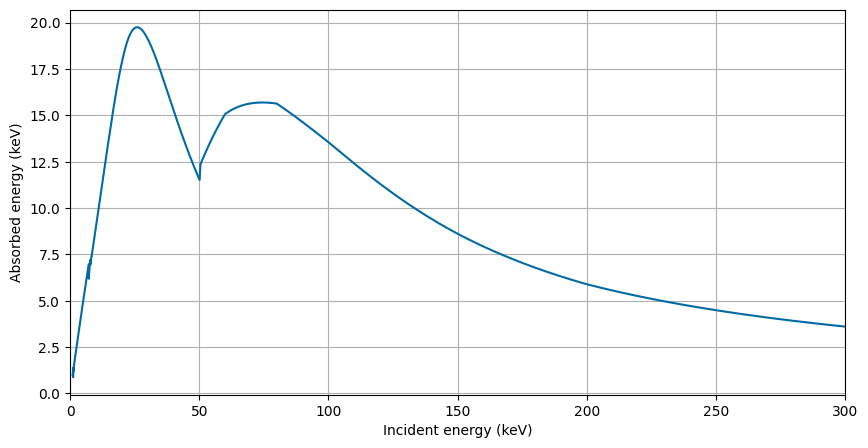

In [14]:
plt.figure(figsize = (10,5))
plt.xlabel("Incident energy (keV)")
plt.ylabel("Absorbed energy (keV)")
plt.plot(energy_response[:,0], energy_response[:,1])
plt.grid()
plt.xlim([0,300])
plt.savefig("detector_response-DRZplus.pdf", bbox_inches='tight')

Retrieve the incident energies corresponding to a 15 keV absorbed energy

In [8]:
print("Incident energy,\tAbsorbed energy")

target_energy = 15

for i in range(energy_response.shape[0]):
    # Prevent out of range access
    if i > 0 and i < energy_response.shape[0]:

        # Select values around 15 keV in absorbed energy
        if energy_response[i-1, 1] < target_energy and energy_response[i, 1] > target_energy or \
                energy_response[i-1, 1] > target_energy and energy_response[i, 1] < target_energy:

            # Select the one that is the closest to target_energy keV
            if abs(energy_response[i-1, 1] - target_energy) < abs(energy_response[i, 1] - target_energy):
                print(f"{round(energy_response[i-1, 0])},\t{round(energy_response[i-1, 1])}")
            else:
                print(f"{round(energy_response[i, 0])},\t{round(energy_response[i, 1])}")

Incident energy,	Absorbed energy
16,	15
41,	15
60,	15
86,	15
